In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

import matplotlib.pyplot as plt
import seaborn as sns
from tueplots import bundles

from wmcal.plots.data import compute_full_summary, load_sweep_data

plt.rcParams.update(bundles.icml2024(usetex=False))
sns.set_theme(style="ticks", font="serif", palette="colorblind")


def get_eids_for_check2_prob(sweep_config_path: str, check2_prob: float):
    import importlib.util

    spec = importlib.util.spec_from_file_location("sweep_config", sweep_config_path)
    assert spec is not None and spec.loader is not None
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return [exp.id for exp in mod.experiments if getattr(exp.calibrator_config, "check2_prob", 1.0) == check2_prob]


## Load Data

Available sweep configs:
- `wmcal/configs/sweep/top_k.py` - Top-K (synthetic)
- `wmcal/configs/sweep/complete_graph.py` - Graph Matching (synthetic_graph)

In [2]:
# Load raw sweep data
configs = ["wmcal/configs/sweep/top_k.py", "wmcal/configs/sweep/complete_graph.py"]
sweep_config = configs[0]
check2_prob = 0.5
raw_df = load_sweep_data(sweep_config)
target_eids = get_eids_for_check2_prob(sweep_config, check2_prob)
raw_df = raw_df.filter(raw_df["eid"].is_in(target_eids))

print(f"check2_prob filter: {check2_prob}")
print(f"Raw data shape: {raw_df.shape}")
raw_df.head()


check2_prob filter: 0.5
Raw data shape: (2213918, 12)


name,value,t,type,g,batch_size,tol,output_dim,top_k,spread,seed,eid
str,f64,i64,str,i64,i32,f64,i32,i32,i32,i32,str
"""mse""",0.087205,0,null,null,16,0.125,4,1,2,42,"""72e5762b1c915acb0f86392219e547…"
"""util""",0.834241,null,"""oracle""",null,16,0.125,4,1,2,42,"""72e5762b1c915acb0f86392219e547…"
"""util""",0.468383,null,"""grid""",0,16,0.125,4,1,2,42,"""72e5762b1c915acb0f86392219e547…"
"""util""",0.632633,null,"""grid""",1,16,0.125,4,1,2,42,"""72e5762b1c915acb0f86392219e547…"
"""util""",0.383878,null,"""grid""",2,16,0.125,4,1,2,42,"""72e5762b1c915acb0f86392219e547…"


## Compute Summary Statistics

In [3]:
# Compute summary with utility and MSE metrics
summary = compute_full_summary(raw_df)

print(f"Summary shape: {summary.shape}")
# Filter for spread = 2
summary = summary.filter(summary["spread"] == 2)
print(f"Summary shape after spread filter: {summary.shape}")

summary.head()

Summary shape: (800, 19)
Summary shape after spread filter: (400, 19)


eid,batch_size,tol,output_dim,top_k,spread,seed,oracle_util,best_grid_util,ew_final_util,ew_pre_util,util_diff_bestgrid,util_oracle_gap_bestgrid,util_diff_self,util_oracle_gap_self,mse_first,mse_last,mse_diff,mse_pct_change
str,i32,f64,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""e88ac67ebfd58e1da934f424488742…",256,0.0625,256,1,2,43,0.986985,0.810234,0.706495,0.493985,-0.103739,0.28049,0.212511,0.28049,0.108111,0.103504,-0.004607,-4.261505
"""04ab19744bf32f63a830f82fc1435c…",1024,0.03125,16,1,2,45,0.9487,0.818396,0.810432,0.569699,-0.007964,0.138268,0.240732,0.138268,0.100064,0.070092,-0.029972,-29.95288
"""335c7163a46fdae65a8d3981a9eebe…",1024,0.0078125,64,1,2,42,0.975287,0.803069,0.523035,0.541694,-0.280034,0.452253,-0.01866,0.452253,0.107626,0.102847,-0.004778,-4.439901
"""7f14c8c5c7724cc46543959d493bf0…",64,0.03125,256,1,2,44,0.986427,0.817203,0.508758,0.519985,-0.308445,0.477669,-0.011227,0.477669,0.107502,0.101969,-0.005533,-5.146828
"""7cf51dd76965f2c9499b2a60746989…",16,0.125,256,1,2,43,0.987211,0.805957,0.682325,0.505963,-0.123632,0.304886,0.176362,0.304886,0.109331,0.104585,-0.004746,-4.340766


## Explore Parameters

In [4]:
print("Batch sizes:", sorted(summary["batch_size"].unique().to_list()))
print("Tolerances:", sorted(summary["tol"].unique().to_list()))
print("Output dims:", sorted(summary["output_dim"].unique().to_list()))
print("Seeds:", sorted(summary["seed"].unique().to_list()))
print("\nNumber of experiments:", len(summary))

Batch sizes: [16, 64, 256, 1024]
Tolerances: [0.0078125, 0.015625, 0.03125, 0.0625, 0.125]
Output dims: [4, 16, 64, 256]
Seeds: [42, 43, 44, 45, 46]

Number of experiments: 400


## Create Plots

Use the plotting functions to visualize results:

/var/folders/1q/qp60k1rj0dj7v4jxbc7cltp40000gn/T/ipykernel_65476/2210922487.py:89: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=2.0, h_pad=2.0)


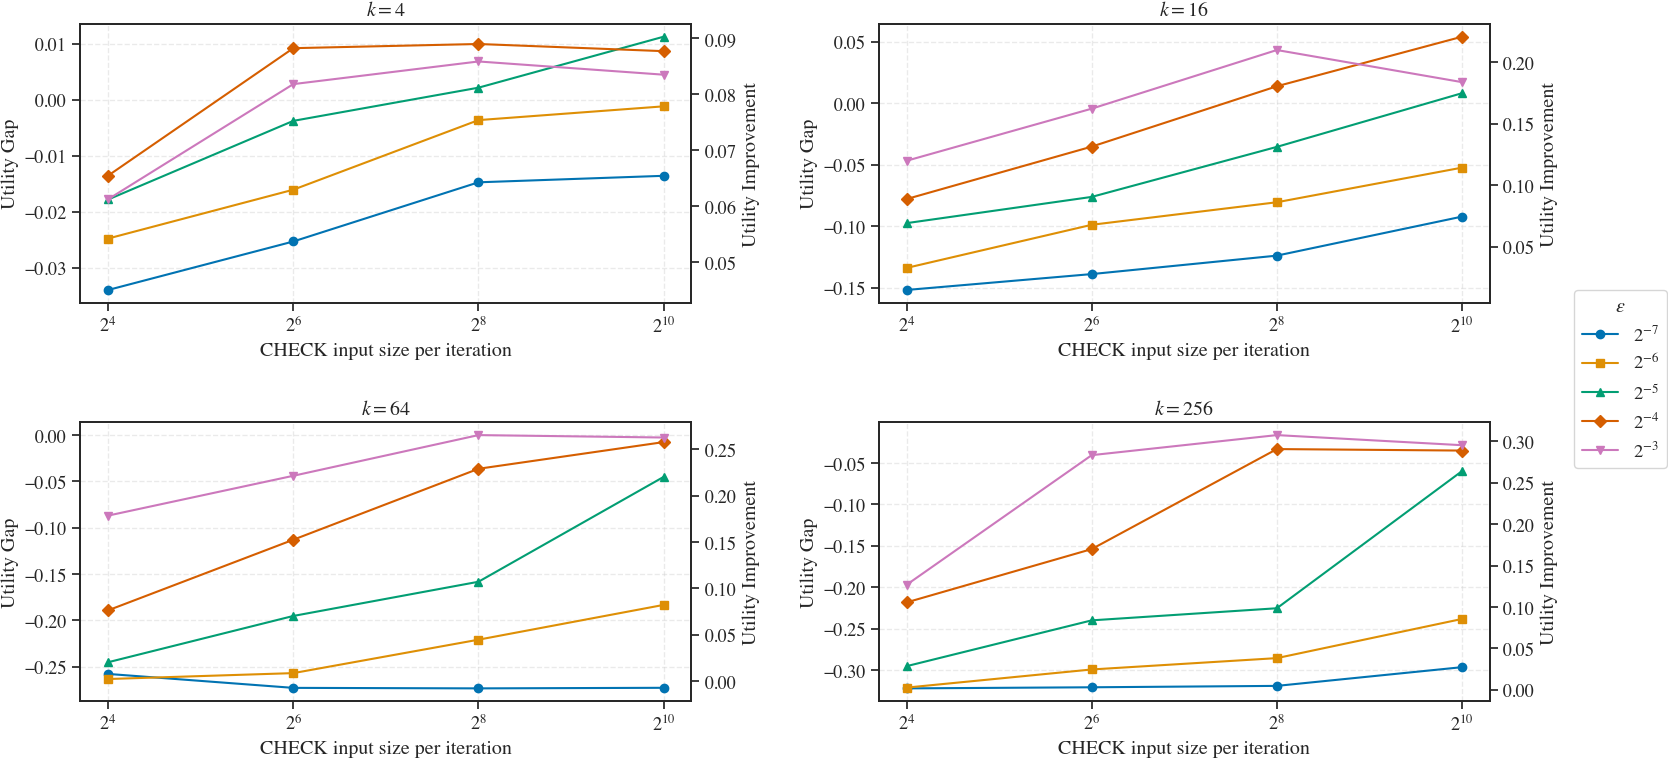

In [5]:
import math

import polars as pl

sns.set_theme(style="ticks", font="serif", palette="colorblind", font_scale=1.2)

# Value Max Utility Plot
y_axis_left = "util_diff_bestgrid"
y_axis_right = "util_diff_self"

output_dims = sorted(summary["output_dim"].unique().to_list())  # length = 4
tols_all = sorted(summary["tol"].unique().to_list())

n_tols = len(tols_all)
n_cols, n_rows = 2, 2

w, h = 8, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(w * n_cols, h * n_rows))
# use discrete colors from the axes color cycle for tolerances
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:n_tols]

# Use list of markers for B&W friendliness
markers = ["o", "s", "^", "D", "v", "<", ">", "p", "*"][:n_tols]

tol_to_color = {tol: colors[i % len(colors)] for i, tol in enumerate(tols_all)}
tol_to_marker = {tol: markers[i % len(markers)] for i, tol in enumerate(tols_all)}

legend_handles = {}


output_dim_2_coord = {
    4: (0, 0),
    16: (0, 1),
    64: (1, 0),
    256: (1, 1),
}

for output_dim in output_dims:
    row_idx, col_idx = output_dim_2_coord[output_dim]
    ax = axes[row_idx, col_idx]
    dim_data = summary.filter((summary["output_dim"] == output_dim))

    ax.set_title(f"$k={output_dim}$")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.set_xlabel("CHECK input size per iteration")
    ax.set_ylabel("Utility Gap")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted(dim_data["batch_size"].unique().to_list()))

    ax2 = ax.twinx()
    ax2.set_ylabel("Utility Improvement")

    for tol in sorted(dim_data["tol"].unique().to_list()):
        sub = dim_data.filter(dim_data["tol"] == tol)
        by_batch = (
            sub.group_by("batch_size")
            .agg(
                pl.col(y_axis_left).mean().alias(y_axis_left),
                pl.col(y_axis_right).mean().alias(y_axis_right),
            )
            .sort("batch_size")
        )

        x = by_batch["batch_size"].to_list()
        left_vals = by_batch[y_axis_left].to_list()
        right_vals = by_batch[y_axis_right].to_list()
        color = tol_to_color[tol]
        marker = tol_to_marker[tol]

        (line,) = ax.plot(
            x,
            left_vals,
            marker=marker,
            color=color,
            label=f"tol={tol}",
        )
        ax2.plot(x, right_vals, color="#00000000")


labels = [f"$2^{{{int(math.log2(t))}}}$" for t in tols_all]

fig.legend(
    labels,
    title="$\\varepsilon$",
    loc="center right",
    bbox_to_anchor=(1.06, 0.5),
)

plt.tight_layout(w_pad=2.0, h_pad=2.0)
fig.savefig("figures/default_utility.pdf", bbox_inches="tight")
plt.show()

Using seed=42, batch_size=1024 for check2_prob=0.5


/var/folders/1q/qp60k1rj0dj7v4jxbc7cltp40000gn/T/ipykernel_65476/925171936.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=2.0, h_pad=2.0)


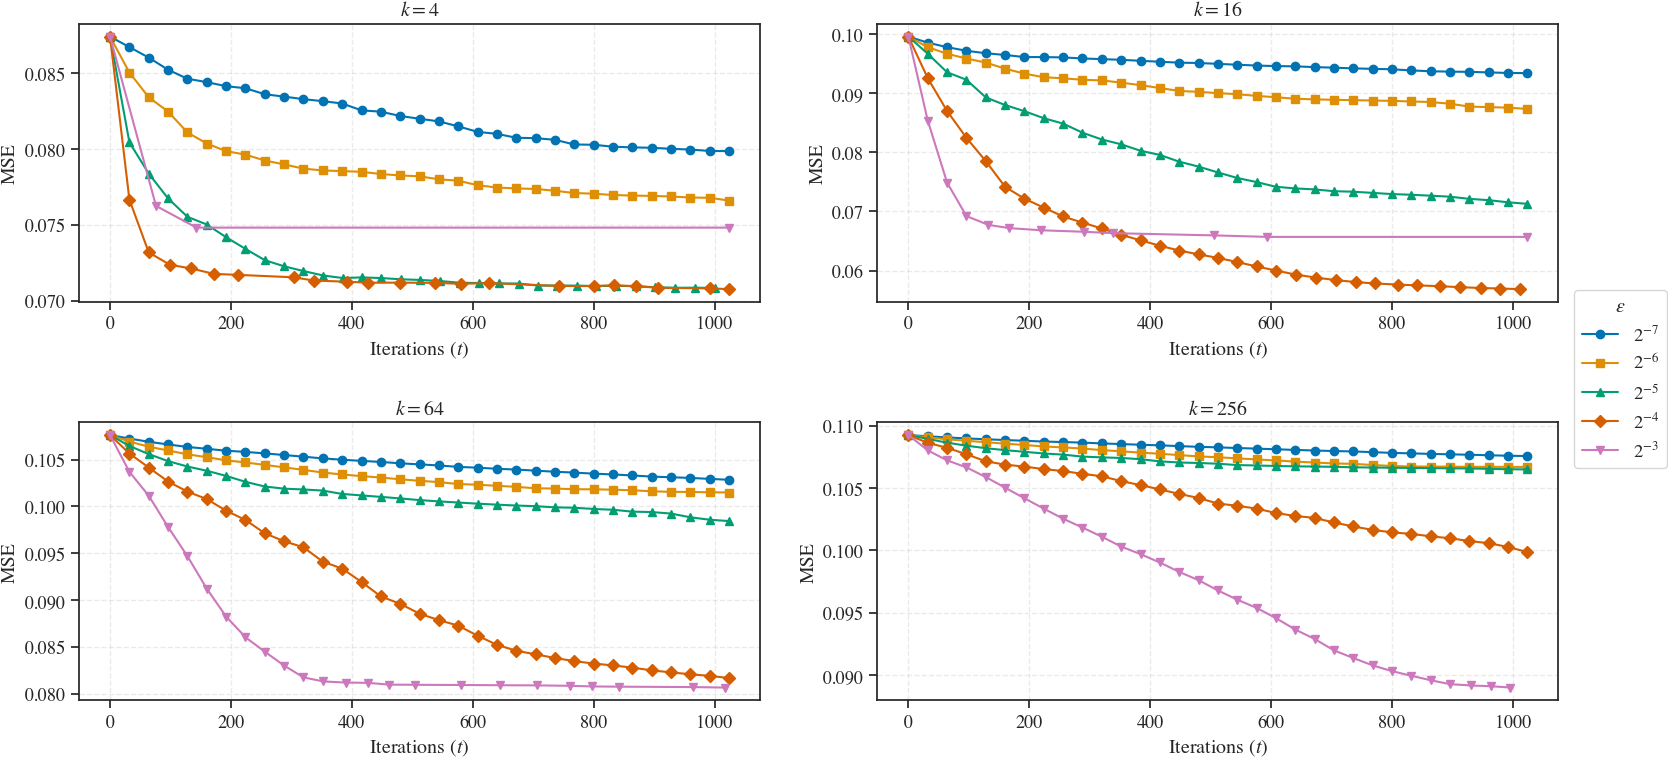

In [6]:
preferred_seed = 42
name = "mse"
preferred_batch_size = 1028
spread = 2
seed_candidates = sorted(raw_df.filter(pl.col("name") == name)["seed"].unique().to_list())
seed = preferred_seed if preferred_seed in seed_candidates else seed_candidates[0]

mse_default_base = raw_df.filter((pl.col("name") == name) & (pl.col("seed") == seed) & (pl.col("spread") == spread))
batch_candidates = sorted(mse_default_base["batch_size"].unique().to_list())
batch_size = preferred_batch_size if preferred_batch_size in batch_candidates else batch_candidates[-1]
mse_default_df = mse_default_base.filter(pl.col("batch_size") == batch_size)

print(f"Using seed={seed}, batch_size={batch_size} for check2_prob={check2_prob}")

output_dims_default = sorted(mse_default_df["output_dim"].unique().to_list())
fig, axes = plt.subplots(n_rows, n_cols, figsize=(w * n_cols, h * n_rows))

for output_dim in output_dims_default:
    row_idx, col_idx = output_dim_2_coord[output_dim]
    ax = axes[row_idx, col_idx]
    dim_data = mse_default_df.filter((mse_default_df["output_dim"] == output_dim))

    ax.set_title(f"$k={output_dim}$")
    ax.set_xlabel("Iterations ($t$)")
    ax.set_ylabel("MSE")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

    for tol in sorted(dim_data["tol"].unique().to_list()):
        sub = dim_data.filter(dim_data["tol"] == tol)

        all_t_values = sorted(sub["t"].unique().to_list())
        sampled_t_values = []
        t = 0
        while t < max(all_t_values) + 10:
            if t in all_t_values:
                sampled_t_values.append(t)
                t += 32
            else:
                t += 1

        sub_sampled = sub.filter(pl.col("t").is_in(sampled_t_values))

        x = sub_sampled["t"].to_list()
        y = sub_sampled["value"].to_list()

        color = tol_to_color[tol]
        marker = tol_to_marker[tol]

        (line,) = ax.plot(x, y, marker=marker, color=color, label=f"tol={tol}")
        if tol not in legend_handles:
            legend_handles[tol] = line


fig.legend(
    labels,
    title="$\\varepsilon$",
    loc="center right",
    bbox_to_anchor=(1.06, 0.5),
)

plt.tight_layout(w_pad=2.0, h_pad=2.0)
fig.savefig("figures/default_mse.pdf", bbox_inches="tight")
plt.show()


## Complete Graphs

In [7]:
# Graph Matching Utility Plot
sweep_config_graph = "wmcal/configs/sweep/complete_graph.py"
raw_df_graph = load_sweep_data(sweep_config_graph)
target_eids_graph = get_eids_for_check2_prob(sweep_config_graph, check2_prob)
raw_df_graph = raw_df_graph.filter(raw_df_graph["eid"].is_in(target_eids_graph))
summary_graph = compute_full_summary(raw_df_graph)
summary_graph = summary_graph.filter(summary_graph["spread"] == 2)

len(summary_graph)

140

In [8]:
summary_graph

eid,batch_size,tol,output_dim,top_k,spread,seed,oracle_util,best_grid_util,ew_final_util,ew_pre_util,util_diff_bestgrid,util_oracle_gap_bestgrid,util_diff_self,util_oracle_gap_self,mse_first,mse_last,mse_diff,mse_pct_change
str,i32,f64,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""89f34666393556cda0b7d6fd873570…",64,0.125,45,1,2,44,4.296502,2.959342,2.752383,2.566598,-0.206959,1.54412,0.185785,1.54412,0.10977,0.101767,-0.008003,-7.290581
"""b583d5a17cbad187a3d2c88dcd5721…",256,0.0625,45,1,2,42,4.271158,2.98815,2.725074,2.590319,-0.263076,1.546084,0.134755,1.546084,0.108855,0.10333,-0.005525,-5.075385
"""b2e1f5d4b2d92f67c0d8f4748703e4…",1024,0.125,45,1,2,45,4.23683,3.007103,3.128857,2.531119,0.121753,1.107974,0.597738,1.107974,0.108454,0.090338,-0.018117,-16.704343
"""2220ef8d964ca0e7ce7580fa661260…",1024,0.5,45,1,2,43,4.255614,3.099822,3.249639,2.699013,0.149817,1.005974,0.550627,1.005974,0.105376,0.089308,-0.016068,-15.247942
"""17669a8292b976c220da90e861070c…",256,0.03125,45,1,2,42,4.271158,2.98815,2.621979,2.590319,-0.366171,1.649179,0.03166,1.649179,0.108855,0.103507,-0.005348,-4.912563
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1904ee461401ff37247c07c67d680d…",256,0.125,45,1,2,44,4.296502,2.959342,2.86546,2.566598,-0.093882,1.431043,0.298862,1.431043,0.10977,0.100259,-0.009511,-8.664591
"""02088beb5dddd59922a01406b96305…",64,0.0625,45,1,2,43,4.255614,3.099822,2.69153,2.699013,-0.408292,1.564083,-0.007482,1.564083,0.105376,0.100241,-0.005135,-4.873261
"""c3eade03f88818610ac8957c43b143…",64,0.5,45,1,2,43,4.255614,3.099822,3.324909,2.699013,0.225087,0.930705,0.625896,0.930705,0.105376,0.079166,-0.02621,-24.872655


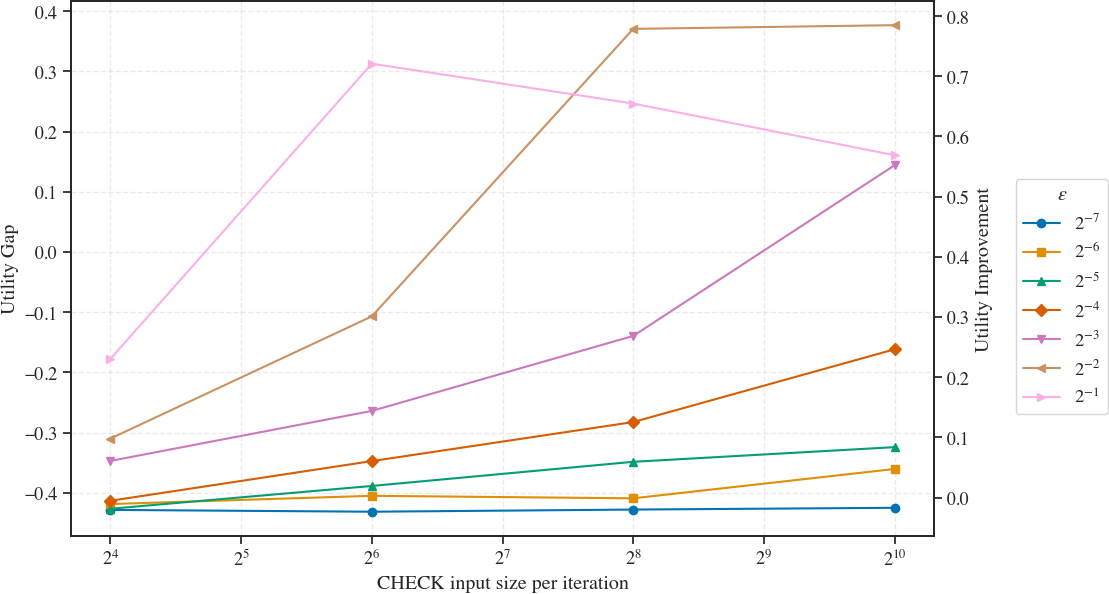

In [9]:
tols_all_graph = sorted(summary_graph["tol"].unique().to_list())
n_tols = len(tols_all_graph)
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:n_tols]
markers = ["o", "s", "^", "D", "v", "<", ">", "p", "*"][:n_tols]
tols_sorted_graph = sorted(tols_all_graph)
tol_to_color_graph = {tol: colors[i % len(colors)] for i, tol in enumerate(tols_sorted_graph)}
tol_to_marker_graph = {tol: markers[i % len(markers)] for i, tol in enumerate(tols_sorted_graph)}


ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.set_xlabel("CHECK input size per iteration")
ax.set_ylabel("Utility Gap")
ax.set_xscale("log", base=2)

ax2 = ax.twinx()
ax2.set_ylabel("Utility Improvement")

for tol in tols_all_graph:
    sub = summary_graph.filter(summary_graph["tol"] == tol)
    by_batch = (
        sub.group_by("batch_size")
        .agg(
            pl.col(y_axis_left).mean().alias(y_axis_left),
            pl.col(y_axis_right).mean().alias(y_axis_right),
        )
        .sort("batch_size")
    )

    x = by_batch["batch_size"].to_list()
    left_vals = by_batch[y_axis_left].to_list()
    right_vals = by_batch[y_axis_right].to_list()
    color = tol_to_color_graph[tol]
    marker = tol_to_marker_graph[tol]

    (line_left,) = ax.plot(x, left_vals, marker=marker, color=color, linestyle="-", label=f"tol={tol}")
    ax2.plot(x, right_vals, marker=marker, color="#00000000", linestyle="--")

labels = [f"$2^{{{int(math.log2(t))}}}$" for t in tols_sorted_graph]
fig.legend(labels, title="$\\varepsilon$", loc="center right", bbox_to_anchor=(1.12, 0.5))
fig.savefig("figures/graph_utility.pdf", bbox_inches="tight")


Using seed=42, batch_size=1024 for graph check2_prob=0.5


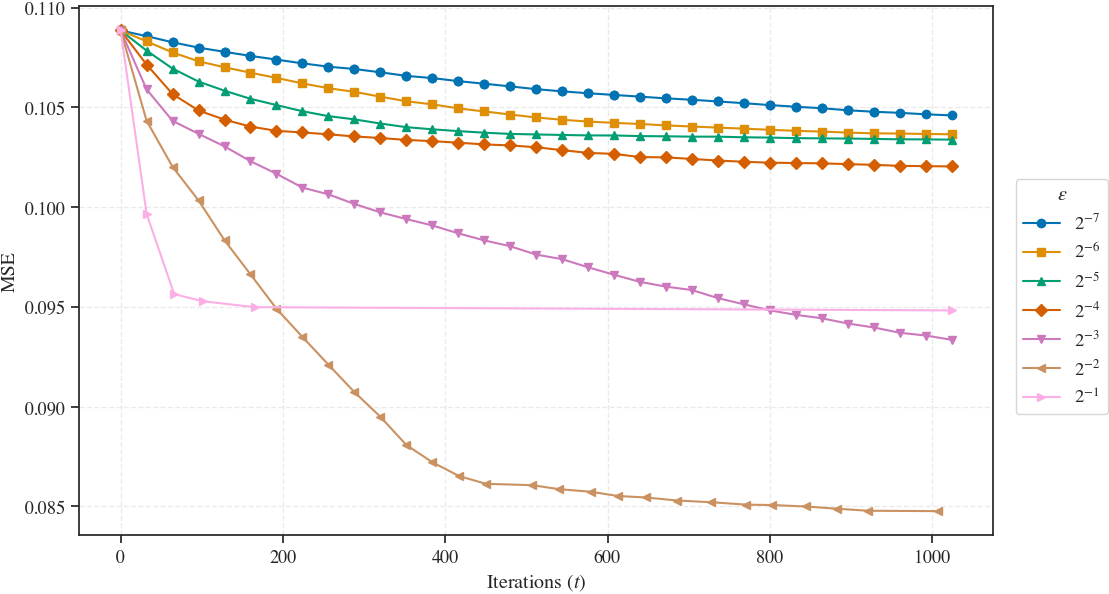

In [10]:
# Graph Matching MSE Plot
preferred_seed = 42
name = "mse"
output_dim = 45
preferred_batch_size = 1028

seed_candidates = sorted(raw_df_graph.filter(pl.col("name") == name)["seed"].unique().to_list())
seed = preferred_seed if preferred_seed in seed_candidates else seed_candidates[0]

mse_graph_base = raw_df_graph.filter(
    (pl.col("name") == name) & (pl.col("seed") == seed) & (pl.col("output_dim") == output_dim)
)
batch_candidates = sorted(mse_graph_base["batch_size"].unique().to_list())
batch_size = preferred_batch_size if preferred_batch_size in batch_candidates else batch_candidates[-1]
batch_data = mse_graph_base.filter(pl.col("batch_size") == batch_size)

print(f"Using seed={seed}, batch_size={batch_size} for graph check2_prob={check2_prob}")

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlabel("Iterations ($t$)")
ax.set_ylabel("MSE")
ax.grid(True, which="both", linestyle="--", alpha=0.4)

for tol in sorted(batch_data["tol"].unique().to_list()):
    sub = batch_data.filter(batch_data["tol"] == tol)

    all_t_values = sorted(sub["t"].unique().to_list())
    sampled_t_values = []
    t = 0
    while t < max(all_t_values) + 10:
        if t in all_t_values:
            sampled_t_values.append(t)
            t += 32
        else:
            t += 1

    sub_sampled = sub.filter(pl.col("t").is_in(sampled_t_values))

    x = sub_sampled["t"].to_list()
    y = sub_sampled["value"].to_list()

    # sort by x and y together
    x, y = zip(*sorted(zip(x, y)))

    color = tol_to_color_graph[tol]
    marker = tol_to_marker_graph[tol]

    (line,) = ax.plot(x, y, marker=marker, color=color, label=f"tol={tol}")
    if tol not in legend_handles:
        legend_handles[tol] = line


labels = [f"$2^{{{int(math.log2(t))}}}$" for t in tols_all_graph]
fig.legend(labels, title="$\\varepsilon$", loc="center right", bbox_to_anchor=(1.12, 0.5))

fig.savefig("figures/graph_mse.pdf", bbox_inches="tight")
plt.show()
